In [1]:
# CELL 1 - Khởi tạo Spark và Đọc HDFS (Đã cập nhật Tagging)
import os
from functools import reduce
from pyspark.sql import SparkSession
import pyspark.sql.functions as F

try:
    spark.stop()
except:
    pass

spark = (
    SparkSession.builder
    .appName("DemandPredictionFeatureEngineering_GCP")
    .master("yarn")
    .config("spark.submit.deployMode", "client")
    .config("spark.eventLog.enabled", "true")
    .config("spark.executor.instances", "3") 
    .config("spark.executor.cores", "3") 
    .config("spark.executor.memory", "8g") 
    .config("spark.executor.memoryOverhead", "2g") 
    .config("spark.driver.memory", "6g") 
    .config("spark.driver.memoryOverhead", "2g") 
    .config("spark.sql.shuffle.partitions", "18")
    .config("spark.sql.parquet.mergeSchema", "false") 
    .config("spark.sql.parquet.enableVectorizedReader", "false")
    .getOrCreate()
)

spark.sparkContext.setLogLevel("WARN")
print(f"Spark Session OK | Master: {spark.sparkContext.master}")

BASE_HDFS = "/user/vietanhdata"
# Cấu trúc thư mục tương ứng với nhãn tập dữ liệu
directories = {
    "train": "/user/data/train",
    "val": "/user/data/val",
    "test": "/user/data/test"
}

COLS_SELECT = [
    F.col("PULocationID").cast("long").alias("PULocationID"),
    F.col("tpep_pickup_datetime").cast("timestamp").alias("tpep_pickup_datetime"),
    F.col("tpep_dropoff_datetime").cast("timestamp").alias("tpep_dropoff_datetime"),
    F.col("trip_distance").cast("double").alias("trip_distance"),
    F.col("total_amount").cast("double").alias("total_amount")
]

print("\nĐang quét, đồng bộ Schema và gắn nhãn (Tagging) từ HDFS...")
FileSystem = spark._jvm.org.apache.hadoop.fs.FileSystem
Path = spark._jvm.org.apache.hadoop.fs.Path
fs = FileSystem.get(spark.sparkContext._jsc.hadoopConfiguration())

dfs = []
for split_name, directory in directories.items():
    try:
        status_list = fs.listStatus(Path(directory))
        for file_status in status_list:
            path_str = str(file_status.getPath())
            if path_str.endswith(".parquet"):
                try:
                    # Đọc file, ép kiểu và GẮN NHÃN 'train', 'val' hoặc 'test'
                    df_file = spark.read.parquet(path_str).select(COLS_SELECT).withColumn("split", F.lit(split_name))
                    dfs.append(df_file)
                except Exception as e:
                    print(f"Lỗi đọc file {path_str}: {e}")
    except Exception as e:
        print(f"Lỗi truy cập thư mục {directory}: {e}")

# Gộp dữ liệu
if len(dfs) > 0:
    df_taxi = reduce(lambda a, b: a.union(b), dfs)
    df_taxi = df_taxi.filter((F.year("tpep_pickup_datetime") >= 2020) & (F.year("tpep_pickup_datetime") <= 2025))
    print(f"Tổng số bản ghi (2020-2025): {df_taxi.count():,}")
else:
    print("[LỖI] Không có file nào được đọc!")

Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/05/31 03:03:03 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
26/05/31 03:03:06 WARN Client: Neither spark.yarn.jars nor spark.yarn.archive is set, falling back to uploading libraries under SPARK_HOME.


Spark Session OK | Master: yarn

Đang quét, đồng bộ Schema và gắn nhãn (Tagging) từ HDFS...


Tổng số bản ghi (2020-2025): 223,410,839


In [2]:
# CELL 2 - Làm sạch + Lọc Outlier + Trích xuất Time bin 30 phút
df_clean = df_taxi.dropna(subset=["PULocationID", "tpep_pickup_datetime", "tpep_dropoff_datetime"])
df_clean = df_clean.filter(
    (F.col("trip_distance") > 0) &
    (F.col("total_amount") > 0)
)

# Loại bỏ tháng 3, 4, 5, 6 năm 2020 (Dữ liệu ngoại lai COVID-19)
df_clean = df_clean.filter(
    ~((F.year("tpep_pickup_datetime") == 2020) & 
      (F.month("tpep_pickup_datetime").isin(3, 4, 5, 6)))
)

# Tạo time_bin 30 phút
df_clean = df_clean.withColumn(
    "time_bin",
    F.date_trunc("hour", F.col("tpep_pickup_datetime")) + 
    F.expr("INTERVAL 30 MINUTES * FLOOR(MINUTE(tpep_pickup_datetime) / 30)")
)

print(f"Số bản ghi sau làm sạch và lọc outlier: {df_clean.count():,}")

Số bản ghi sau làm sạch và lọc outlier: 212,848,994


Tìm optimal K sử dụng Elbow Method...


26/05/31 03:08:34 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.blas.JNIBLAS


K=5: WSS=8501342964613.82


K=10: WSS=2558852505076.44


K=15: WSS=647231600994.80


...

K=30: WSS=57159106739.49


K=35: WSS=46023186859.57


K=40: WSS=22591877618.52


K=45: WSS=16338599172.27


K=50: WSS=6270171133.62


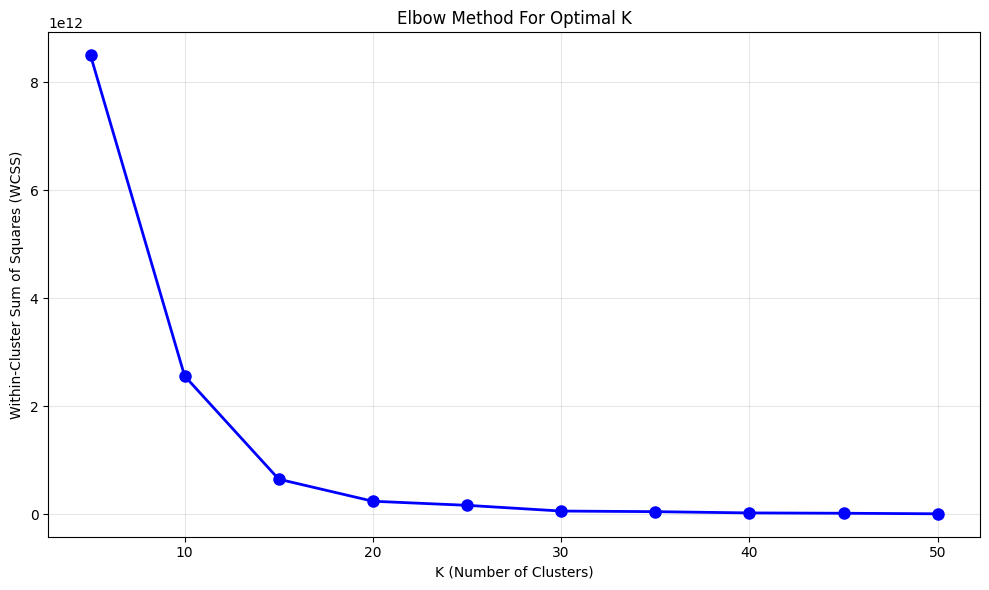

Elbow Method hoàn tất. Chọn K dựa trên đồ thị trên.


In [3]:
# CELL 2B - K-Means Elbow Method (Tìm optimal K)
from pyspark.ml.clustering import KMeans
from pyspark.ml.feature import VectorAssembler
import matplotlib.pyplot as plt

print("Tìm optimal K sử dụng Elbow Method...")

df_train = df_clean.filter(F.col("split") == "train")
zone_summary_train = df_train.groupBy("PULocationID").agg(
    F.count("*").alias("total_demand"),
    F.avg("trip_distance").alias("avg_distance")
)

assembler = VectorAssembler(inputCols=["total_demand", "avg_distance"], outputCol="features")
zone_summary_vec = assembler.transform(zone_summary_train)

# Test K từ 5 đến 50
k_values = [5, 10, 15, 20, 25, 30, 35, 40, 45, 50]
inertias = []

for k in k_values:
    kmeans = KMeans(k=k, seed=42, featuresCol="features")
    kmeans_model = kmeans.fit(zone_summary_vec)
    inertias.append(kmeans_model.summary.trainingCost)
    print(f"K={k}: WSS={kmeans_model.summary.trainingCost:.2f}")

# Vẽ Elbow Curve
plt.figure(figsize=(10, 6))
plt.plot(k_values, inertias, 'bo-', linewidth=2, markersize=8)
plt.xlabel('K (Number of Clusters)')
plt.ylabel('Within-Cluster Sum of Squares (WCSS)')
plt.title('Elbow Method For Optimal K')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("Elbow Method hoàn tất. Chọn K dựa trên đồ thị trên.")


In [ ]:
# CELL 3 - K-Means Clustering trên dữ liệu tóm tắt 
from pyspark.ml.clustering import KMeans
from pyspark.ml.feature import VectorAssembler

print("Đang tạo bảng tóm tắt đặc trưng cho từng Zone (Chỉ dùng tập TRAIN)...")
# CHỈ DÙNG TẬP TRAIN ĐỂ TRÁNH RÒ RỈ DỮ LIỆU
df_train = df_clean.filter(F.col("split") == "train")

zone_summary_train = df_train.groupBy("PULocationID").agg(
    F.count("*").alias("total_demand"),
    F.avg("trip_distance").alias("avg_distance")
)

assembler = VectorAssembler(inputCols=["total_demand", "avg_distance"], outputCol="features")
zone_summary_vec = assembler.transform(zone_summary_train)

print("Đang huấn luyện mô hình K-Means (K=40 cụm)...")
kmeans = KMeans(k=40, seed=42, featuresCol="features", predictionCol="cluster_id")
kmeans_model = kmeans.fit(zone_summary_vec)

# Lấy nhãn cluster_id đã huấn luyện
clustered_zones = kmeans_model.transform(zone_summary_vec).select("PULocationID", "cluster_id")

df_clustered = df_clean.join(clustered_zones, on="PULocationID", how="left")

# Kiểm tra zones không được gán cluster_id
unmapped_zones = df_clustered.filter(F.col("cluster_id").isNull()).select("PULocationID").distinct().count()
print(f"Hoàn tất gom cụm. Zones không được map: {unmapped_zones}")
if unmapped_zones > 0:
    print("Cảnh báo: Có zones trong val/test không có cluster_id từ train data")


Đang tạo bảng tóm tắt đặc trưng cho từng Zone (Chỉ dùng tập TRAIN)...
Đang huấn luyện mô hình K-Means (K=40 cụm)...


26/05/31 03:32:30 WARN DAGScheduler: Broadcasting large task binary with size 1681.4 KiB


Hoàn tất gom cụm. Zones không được map: 0


In [5]:
# CELL 4 - Tính tổng hợp Demand và Tỷ trọng phân rã (Bản thuần PySpark)
print("Đang tổng hợp Demand theo thời gian và tạo đặc trưng chuỗi thời gian...")

from pyspark.sql.window import Window
import pyspark.sql.functions as F

# --- BƯỚC 1: Tính Zone-Level Demand ---
zone_demand_df = df_clustered.groupBy("time_bin", "cluster_id", "PULocationID").agg(
    F.count("*").alias("zone_demand"),
    F.max("split").alias("split")  
)

zone_window = Window.partitionBy("PULocationID").orderBy("time_bin")
zone_demand_df = zone_demand_df.withColumn(
    "true_zone_t_plus_1", F.lead("zone_demand", 1).over(zone_window)
).cache()

# --- BƯỚC 2: Tính Cluster-Level Demand ---
cluster_demand_df = zone_demand_df.groupBy("time_bin", "cluster_id").agg(
    F.sum("zone_demand").alias("cluster_demand"),
    F.max("split").alias("split")  
).cache()

# --- BƯỚC 3: Tạo Target t+1 và Đặc trưng độ trễ ---
window_spec = Window.partitionBy("cluster_id").orderBy("time_bin")

cluster_demand_with_features = cluster_demand_df.withColumn(
    "target_t_plus_1", F.lead("cluster_demand", 1).over(window_spec)
).withColumn("lag_1", F.lag("cluster_demand", 1).over(window_spec)) \
 .withColumn("lag_2", F.lag("cluster_demand", 2).over(window_spec)) \
 .withColumn("lag_3", F.lag("cluster_demand", 3).over(window_spec)) \
 .withColumn("lag_48", F.lag("cluster_demand", 48).over(window_spec)) \
 .withColumn("lag_336", F.lag("cluster_demand", 336).over(window_spec))

cluster_demand_with_target = cluster_demand_with_features.dropna(
    subset=["target_t_plus_1", "lag_1", "lag_2", "lag_3", "lag_48", "lag_336"]
).cache()

print(f"Số bản ghi Cluster-Level (sau khi dropna): {cluster_demand_with_target.count():,}")

# --- BƯỚC 4: Tính tỷ trọng phân rã (Trực tiếp trên Spark) ---
print("Đang tính tỷ trọng phân rã (từ TRAIN data)...")
zone_demand_train = zone_demand_df.filter(F.col("split") == "train")

zone_total = zone_demand_train.groupBy("cluster_id", "PULocationID").agg(
    F.sum("zone_demand").alias("zone_total")
)

cluster_total = zone_demand_train.groupBy("cluster_id").agg(
    F.sum("zone_demand").alias("cluster_total")
)

# Lưu lại DataFrame này để dùng trong hàm Evaluate
ratios_spark = zone_total.join(
    cluster_total, on="cluster_id", how="inner"
).withColumn(
    "proportion", F.col("zone_total") / F.col("cluster_total")
).select("cluster_id", "PULocationID", "proportion").cache()

# --- BƯỚC 5: Lưu Spark DataFrames ---
cluster_demand_with_target.write.mode("overwrite").parquet(
    "hdfs:///user/vietanhdata/cluster_demand_features"
)
print("Đã lưu cluster_demand_features vào HDFS")

print("Cleanup: Giải phóng memory cache không còn dùng...")


Đang tổng hợp Demand theo thời gian và tạo đặc trưng chuỗi thời gian...


26/05/31 03:34:41 WARN DAGScheduler: Broadcasting large task binary with size 1784.1 KiB
26/05/31 03:35:29 WARN DAGScheduler: Broadcasting large task binary with size 1791.1 KiB
26/05/31 03:35:32 WARN DAGScheduler: Broadcasting large task binary with size 1797.1 KiB
26/05/31 03:35:35 WARN DAGScheduler: Broadcasting large task binary with size 1798.6 KiB
26/05/31 03:35:35 WARN DAGScheduler: Broadcasting large task binary with size 1813.7 KiB
26/05/31 03:35:39 WARN DAGScheduler: Broadcasting large task binary with size 1818.4 KiB


Số bản ghi Cluster-Level (sau khi dropna): 3,829,836
Đang tính tỷ trọng phân rã (từ TRAIN data)...


26/05/31 03:35:41 WARN DAGScheduler: Broadcasting large task binary with size 2021.6 KiB


Đã lưu cluster_demand_features vào HDFS
Cleanup: Giải phóng memory cache không còn dùng...


In [6]:
# CELL 5 - Cài đặt thư viện ML
import os, glob

offline_dir = "/workspace/code/taxiflow_nyc/offline_packages"
if os.path.exists(offline_dir) and glob.glob(os.path.join(offline_dir, "*.whl")):
    print("Cài offline...")
    !pip install --no-index --find-links=file://{offline_dir} scikit-learn xgboost pandas
else:
    print("Cài online...")
    !pip install scikit-learn xgboost joblib pyarrow pandas

Cài online...


In [7]:
# CELL 6 - Lưu Data (CSV LOCAL + HDFS)
import os

print("Đang lưu dữ liệu...")


BASE_HDFS = "/user/vietanhdata"
hdfs_path = f"{BASE_HDFS}/cluster_demand_features"

try:
    cluster_demand_df.write.mode("overwrite").parquet(hdfs_path)
    print(f"Lưu HDFS: {hdfs_path}")
except Exception as e:
    print(f"Lưu HDFS thất bại: {e}")
    print("  (Có thể đã lưu ở Cell 4)")

Đang lưu dữ liệu...


26/05/31 03:35:48 WARN DAGScheduler: Broadcasting large task binary with size 2003.9 KiB


Lưu HDFS: /user/vietanhdata/cluster_demand_features


In [ ]:
# CELL 7 - Chuẩn bị ML Data với LAG FEATURES và VectorAssembler
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.evaluation import RegressionEvaluator
import pyspark.sql.functions as F

print("Đang bóc tách đặc trưng thời gian bằng PySpark...")

# 1. Trích xuất đặc trưng thời gian
# Lưu ý: PySpark dayofweek() quy định Chủ Nhật = 1, Thứ Bảy = 7
pdf_cluster_spark = cluster_demand_with_target.withColumn("hour", F.hour("time_bin")) \
    .withColumn("day_of_week", F.dayofweek("time_bin")) \
    .withColumn("month", F.month("time_bin")) \
    .withColumn("is_weekend", F.when(F.col("day_of_week").isin([1, 7]), 1).otherwise(0))

feature_cols = [
    'cluster_id', 'hour', 'day_of_week', 'is_weekend', 'month',
    'lag_1', 'lag_2', 'lag_3', 'lag_48', 'lag_336'  # Chỉ dùng lag features
]

# 2. VectorAssembler: Gom các features thành cột 'features'
print(f"Before VectorAssembler: {pdf_cluster_spark.count():,} rows")
assembler = VectorAssembler(inputCols=feature_cols, outputCol="features", handleInvalid="skip")
ml_data = assembler.transform(pdf_cluster_spark)
rows_after = ml_data.count()
print(f"After VectorAssembler: {rows_after:,} rows")
print(f"Rows dropped (NULL values): {pdf_cluster_spark.count() - rows_after:,}")

# 3. Chia tập train/val/test
train_data = ml_data.filter(F.col("split") == "train").cache()
val_data = ml_data.filter(F.col("split") == "val").cache()
test_data = ml_data.filter(F.col("split") == "test").cache()

print(f"Kích thước tập - Train: {train_data.count():,}, Valid: {val_data.count():,}, Test: {test_data.count():,}")

# 4. Hàm đánh giá trên Spark DataFrame
def evaluate_disaggregated_model_spark(model_name, model, test_df, zone_demand_df, ratios_spark):
    print(f"Đang dự đoán và đánh giá cho {model_name}...")
    
    # Dự đoán cấp Cluster
    predictions = model.transform(test_df)
    
    # Lấy nhãn của tập đang đánh giá (ví dụ 'test')
    split_name = test_df.select("split").first()[0]
    
    # Lọc zone data theo split
    zone_filtered = zone_demand_df.filter(F.col("split") == split_name)
    
    # Kết hợp (Join) để xuống cấp Zone
    # predictions có cột 'prediction' là kết quả dự đoán của model
    eval_zone = zone_filtered.join(
        predictions.select("time_bin", "cluster_id", F.col("prediction").alias("pred_cluster_demand")),
        on=["time_bin", "cluster_id"], how="inner"
    )
    
    eval_zone = eval_zone.join(ratios_spark, on=["cluster_id", "PULocationID"], how="left")
    
    null_proportion = eval_zone.filter(F.col("proportion").isNull()).count()
    if null_proportion > 0:
        print(f"  {null_proportion} rows có proportion = NULL, loại bỏ...")
        eval_zone = eval_zone.dropna(subset=["proportion"])
    
    # Tính predicted zone demand
    eval_zone = eval_zone.withColumn("pred_zone_demand", F.col("pred_cluster_demand") * F.col("proportion"))
    eval_zone = eval_zone.dropna(subset=["true_zone_t_plus_1", "pred_zone_demand"])
    
    # Đánh giá RMSE, MAE, R2 bằng RegressionEvaluator
    evaluator_rmse = RegressionEvaluator(labelCol="true_zone_t_plus_1", predictionCol="pred_zone_demand", metricName="rmse")
    evaluator_mae = RegressionEvaluator(labelCol="true_zone_t_plus_1", predictionCol="pred_zone_demand", metricName="mae")
    evaluator_r2 = RegressionEvaluator(labelCol="true_zone_t_plus_1", predictionCol="pred_zone_demand", metricName="r2")
    
    rmse = evaluator_rmse.evaluate(eval_zone)
    mae = evaluator_mae.evaluate(eval_zone)
    r2 = evaluator_r2.evaluate(eval_zone)
    
    # MAPE = mean(|actual - pred| / |actual|)
    eval_zone = eval_zone.withColumn(
        "abs_pct_error",
        F.when(F.col("true_zone_t_plus_1") == 0, 0)  # Nếu actual = 0, error = 0
        .otherwise(F.abs((F.col("true_zone_t_plus_1") - F.col("pred_zone_demand")) / F.abs(F.col("true_zone_t_plus_1"))))
    )
    mape = eval_zone.select(F.avg("abs_pct_error")).collect()[0][0] * 100

    
    print(f"--- {model_name} ({split_name.upper()}) (Zone-Level) ---")
    print(f"RMSE : {rmse:.4f}")
    print(f"MAE  : {mae:.4f}")
    print(f"MAPE : {mape:.4f}%")
    print(f"R2   : {r2:.4f}\n")


Đang bóc tách đặc trưng thời gian bằng PySpark...


26/05/31 03:35:51 WARN DAGScheduler: Broadcasting large task binary with size 1818.4 KiB


Before VectorAssembler: 3,829,836 rows


26/05/31 03:35:52 WARN DAGScheduler: Broadcasting large task binary with size 1825.0 KiB


After VectorAssembler: 3,829,836 rows


26/05/31 03:35:53 WARN DAGScheduler: Broadcasting large task binary with size 1818.4 KiB


Rows dropped (NULL values): 0


26/05/31 03:35:55 WARN DAGScheduler: Broadcasting large task binary with size 1847.3 KiB
26/05/31 03:36:00 WARN DAGScheduler: Broadcasting large task binary with size 1851.6 KiB
26/05/31 03:36:01 WARN DAGScheduler: Broadcasting large task binary with size 1847.3 KiB
26/05/31 03:36:03 WARN DAGScheduler: Broadcasting large task binary with size 1851.6 KiB
26/05/31 03:36:04 WARN DAGScheduler: Broadcasting large task binary with size 1847.3 KiB
26/05/31 03:36:07 WARN DAGScheduler: Broadcasting large task binary with size 1851.6 KiB


Kích thước tập - Train: 2,565,184, Valid: 400,909, Test: 863,743


In [9]:
# CELL 8 - Linear Regression (Spark MLlib)
from pyspark.ml.regression import LinearRegression

print("Huấn luyện Linear Regression (Cluster-Level)...")

# Cấu hình mô hình
lr = LinearRegression(featuresCol="features", labelCol="target_t_plus_1", fitIntercept=True)

# Khởi tạo mô hình
lr_model = lr.fit(train_data)

# Đánh giá trên tập Test
evaluate_disaggregated_model_spark("Linear Regression", lr_model, test_data, zone_demand_df, ratios_spark)

Huấn luyện Linear Regression (Cluster-Level)...


26/05/31 03:36:08 WARN Instrumentation: [ddc5794e] regParam is zero, which might cause numerical instability and overfitting.
26/05/31 03:36:08 WARN DAGScheduler: Broadcasting large task binary with size 1882.5 KiB
26/05/31 03:36:10 WARN DAGScheduler: Broadcasting large task binary with size 1883.6 KiB
26/05/31 03:36:10 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.lapack.JNILAPACK
26/05/31 03:36:11 WARN DAGScheduler: Broadcasting large task binary with size 1868.3 KiB
26/05/31 03:36:12 WARN DAGScheduler: Broadcasting large task binary with size 1869.4 KiB


Đang dự đoán và đánh giá cho Linear Regression...


26/05/31 03:36:13 WARN DAGScheduler: Broadcasting large task binary with size 1848.5 KiB
26/05/31 03:36:15 WARN DAGScheduler: Broadcasting large task binary with size 1810.8 KiB
26/05/31 03:36:15 WARN DAGScheduler: Broadcasting large task binary with size 1801.9 KiB
26/05/31 03:36:17 WARN DAGScheduler: Broadcasting large task binary with size 1818.0 KiB
26/05/31 03:36:17 WARN DAGScheduler: Broadcasting large task binary with size 1791.0 KiB
26/05/31 03:36:17 WARN DAGScheduler: Broadcasting large task binary with size 1851.7 KiB
26/05/31 03:36:18 WARN DAGScheduler: Broadcasting large task binary with size 1822.3 KiB
26/05/31 03:36:19 WARN DAGScheduler: Broadcasting large task binary with size 1910.8 KiB
26/05/31 03:36:21 WARN DAGScheduler: Broadcasting large task binary with size 1791.3 KiB
26/05/31 03:36:21 WARN DAGScheduler: Broadcasting large task binary with size 1861.9 KiB
26/05/31 03:36:22 WARN DAGScheduler: Broadcasting large task binary with size 1822.3 KiB
26/05/31 03:36:23 WAR

--- Linear Regression (TEST) (Zone-Level) ---
RMSE : 15.1573
MAE  : 6.8503
MAPE : 76.7112%
R2   : 0.8494



In [10]:
# CELL 9 - Random Forest (Spark MLlib)
from pyspark.ml.regression import RandomForestRegressor

print("Huấn luyện Random Forest (Cluster-Level)...")

rf = RandomForestRegressor(
    featuresCol="features", 
    labelCol="target_t_plus_1", 
    numTrees=50, 
    maxDepth=10, 
    seed=42
)

rf_model = rf.fit(train_data)

# Đánh giá trên tập Test
evaluate_disaggregated_model_spark("Random Forest", rf_model, test_data, zone_demand_df, ratios_spark)

Huấn luyện Random Forest (Cluster-Level)...


26/05/31 03:36:37 WARN DAGScheduler: Broadcasting large task binary with size 1880.6 KiB
26/05/31 03:36:37 WARN DAGScheduler: Broadcasting large task binary with size 1880.7 KiB
26/05/31 03:36:37 WARN DAGScheduler: Broadcasting large task binary with size 1883.5 KiB
26/05/31 03:36:38 WARN DAGScheduler: Broadcasting large task binary with size 1890.4 KiB
26/05/31 03:36:44 WARN DAGScheduler: Broadcasting large task binary with size 1907.6 KiB
26/05/31 03:36:47 WARN DAGScheduler: Broadcasting large task binary with size 1938.1 KiB
26/05/31 03:36:50 WARN DAGScheduler: Broadcasting large task binary with size 1999.9 KiB
26/05/31 03:36:55 WARN DAGScheduler: Broadcasting large task binary with size 2.1 MiB
26/05/31 03:37:00 WARN DAGScheduler: Broadcasting large task binary with size 2.3 MiB
26/05/31 03:37:08 WARN DAGScheduler: Broadcasting large task binary with size 2.8 MiB
26/05/31 03:37:17 WARN DAGScheduler: Broadcasting large task binary with size 3.8 MiB
26/05/31 03:37:30 WARN DAGSchedul

Đang dự đoán và đánh giá cho Random Forest...


26/05/31 03:38:15 WARN DAGScheduler: Broadcasting large task binary with size 1848.5 KiB
26/05/31 03:38:18 WARN DAGScheduler: Broadcasting large task binary with size 1791.0 KiB
26/05/31 03:38:18 WARN DAGScheduler: Broadcasting large task binary with size 1851.7 KiB
26/05/31 03:38:19 WARN DAGScheduler: Broadcasting large task binary with size 1822.3 KiB
26/05/31 03:38:20 WARN DAGScheduler: Broadcasting large task binary with size 1910.6 KiB
26/05/31 03:38:22 WARN DAGScheduler: Broadcasting large task binary with size 1791.3 KiB
26/05/31 03:38:22 WARN DAGScheduler: Broadcasting large task binary with size 1859.9 KiB
26/05/31 03:38:23 WARN DAGScheduler: Broadcasting large task binary with size 1822.3 KiB
26/05/31 03:38:27 WARN DAGScheduler: Broadcasting large task binary with size 1923.6 KiB
26/05/31 03:38:28 WARN DAGScheduler: Broadcasting large task binary with size 1924.7 KiB
26/05/31 03:38:29 WARN DAGScheduler: Broadcasting large task binary with size 1791.3 KiB
26/05/31 03:38:29 WAR

--- Random Forest (TEST) (Zone-Level) ---
RMSE : 14.2368
MAE  : 6.2448
MAPE : 65.5367%
R2   : 0.8671



In [11]:
# CELL 10 - Gradient-Boosted Trees (Tương đương XGBoost)
from pyspark.ml.regression import GBTRegressor

print("Huấn luyện GBTRegressor (Cluster-Level)...")

gbt = GBTRegressor(
    featuresCol="features", 
    labelCol="target_t_plus_1", 
    maxIter=50,      # Số lượng cây (n_estimators)
    maxDepth=7, 
    stepSize=0.05,   # Learning rate
    seed=42
)

gbt_model = gbt.fit(train_data)

# Đánh giá trên tập Test
evaluate_disaggregated_model_spark("Gradient-Boosted Trees", gbt_model, test_data, zone_demand_df, ratios_spark)

Huấn luyện GBTRegressor (Cluster-Level)...


26/05/31 03:38:52 WARN DAGScheduler: Broadcasting large task binary with size 1879.9 KiB
26/05/31 03:38:53 WARN DAGScheduler: Broadcasting large task binary with size 1880.0 KiB
26/05/31 03:38:53 WARN DAGScheduler: Broadcasting large task binary with size 1882.9 KiB
26/05/31 03:38:54 WARN DAGScheduler: Broadcasting large task binary with size 1886.4 KiB
26/05/31 03:38:55 WARN DAGScheduler: Broadcasting large task binary with size 1887.2 KiB
26/05/31 03:38:56 WARN DAGScheduler: Broadcasting large task binary with size 1887.8 KiB
26/05/31 03:38:56 WARN DAGScheduler: Broadcasting large task binary with size 1888.9 KiB
26/05/31 03:38:57 WARN DAGScheduler: Broadcasting large task binary with size 1891.2 KiB
26/05/31 03:38:57 WARN DAGScheduler: Broadcasting large task binary with size 1895.7 KiB
26/05/31 03:38:58 WARN DAGScheduler: Broadcasting large task binary with size 1904.8 KiB
26/05/31 03:38:58 WARN DAGScheduler: Broadcasting large task binary with size 1912.9 KiB
26/05/31 03:38:59 WAR

Đang dự đoán và đánh giá cho Gradient-Boosted Trees...


26/05/31 03:42:07 WARN DAGScheduler: Broadcasting large task binary with size 1848.5 KiB
26/05/31 03:42:10 WARN DAGScheduler: Broadcasting large task binary with size 1791.0 KiB
26/05/31 03:42:10 WARN DAGScheduler: Broadcasting large task binary with size 1851.7 KiB
26/05/31 03:42:10 WARN DAGScheduler: Broadcasting large task binary with size 1822.3 KiB
26/05/31 03:42:11 WARN DAGScheduler: Broadcasting large task binary with size 1910.6 KiB
26/05/31 03:42:13 WARN DAGScheduler: Broadcasting large task binary with size 1791.3 KiB
26/05/31 03:42:13 WARN DAGScheduler: Broadcasting large task binary with size 1859.9 KiB
26/05/31 03:42:13 WARN DAGScheduler: Broadcasting large task binary with size 1822.3 KiB
26/05/31 03:42:15 WARN DAGScheduler: Broadcasting large task binary with size 1923.6 KiB
26/05/31 03:42:16 WARN DAGScheduler: Broadcasting large task binary with size 1924.7 KiB
26/05/31 03:42:17 WARN DAGScheduler: Broadcasting large task binary with size 1791.3 KiB
26/05/31 03:42:17 WAR

--- Gradient-Boosted Trees (TEST) (Zone-Level) ---
RMSE : 13.9752
MAE  : 6.1945
MAPE : 65.4471%
R2   : 0.8720



Đang trích xuất và vẽ Feature Importance Chart từ mô hình Spark MLlib...
Feature Importance:
       Feature  Importance
5        lag_1    0.679703
1         hour    0.100000
0   cluster_id    0.070431
8       lag_48    0.043971
9      lag_336    0.026932
7        lag_3    0.023591
2  day_of_week    0.021394
6        lag_2    0.014790
4        month    0.010791
3   is_weekend    0.008398



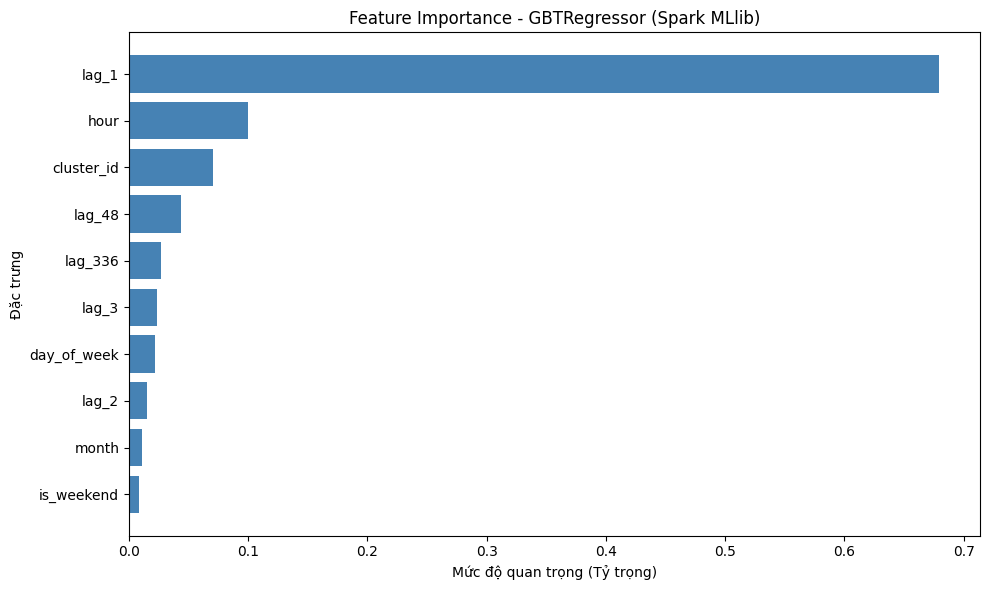

In [ ]:
# CELL 11 - Feature Importance (Spark MLlib)
import matplotlib.pyplot as plt
import pandas as pd
import os

print("Đang trích xuất và vẽ Feature Importance Chart từ mô hình Spark MLlib...")

try:
    # Lấy mảng tầm quan trọng của các đặc trưng từ mô hình GBT
    importances = gbt_model.featureImportances.toArray()
    
    # Biến feature_cols đã được khai báo ở Cell 7 trong quá trình tạo VectorAssembler
    feature_df = pd.DataFrame({
        'Feature': feature_cols,
        'Importance': importances
    }).sort_values('Importance', ascending=False)
    
    print(f"Feature Importance:\n{feature_df}\n")
    
except Exception as e:
    print(f" Lỗi tạo DataFrame lấy Feature Importance: {e}")
    raise

# Vẽ biểu đồ
try:
    plt.figure(figsize=(10, 6))
    
    # Sắp xếp lại để đặc trưng quan trọng nhất nằm trên cùng của biểu đồ
    feature_df_plot = feature_df.sort_values('Importance', ascending=True)
    
    plt.barh(feature_df_plot['Feature'], feature_df_plot['Importance'], color='steelblue')
    plt.xlabel('Mức độ quan trọng (Tỷ trọng)')
    plt.ylabel('Đặc trưng')
    plt.title('Feature Importance - GBTRegressor (Spark MLlib)')
    plt.tight_layout()
    

    plt.show()
    
except ImportError as e:
    print(f" Lỗi import: {e}")
    print("   Giải pháp: Kiểm tra lại thư viện matplotlib")
    raise
except Exception as e:
    print(f" Lỗi vẽ biểu đồ: {e}")
    raise

In [ ]:
# CELL 12 - Cleanup Memory + Hyperparameter Tuning trên Validation Set
print("Đang làm sạch cache và giải phóng memory...")

zone_demand_df.unpersist()
cluster_demand_df.unpersist()
cluster_demand_with_target.unpersist()
ratios_spark.unpersist()

print(" Memory cleanup hoàn tất\n")

# Hyperparameter Tuning trên Validation Set 
print("=== HYPERPARAMETER TUNING TRÊN VALIDATION SET ===\n")

from pyspark.ml.regression import RandomForestRegressor, GBTRegressor
from pyspark.ml.tuning import ParamGridBuilder, CrossValidator
from pyspark.ml.evaluation import RegressionEvaluator

# Tuning Random Forest
print("Tuning Random Forest numTrees...")
rf_param_grid = ParamGridBuilder() \
    .addGrid(RandomForestRegressor().numTrees, [30, 50, 100]) \
    .addGrid(RandomForestRegressor().maxDepth, [8, 10, 12]) \
    .build()

rf_evaluator = RegressionEvaluator(labelCol="target_t_plus_1", predictionCol="prediction", metricName="rmse")
rf = RandomForestRegressor(seed=42, featuresCol="features", labelCol="target_t_plus_1")

rf_cv = CrossValidator(estimator=rf, estimatorParamMaps=rf_param_grid, evaluator=rf_evaluator, numFolds=3)
rf_cv_model = rf_cv.fit(train_data)

print("Random Forest - Best params:")
print(f"  numTrees: {rf_cv_model.bestModel.getNumTrees}")
print(f"  maxDepth: {rf_cv_model.bestModel.getMaxDepth}")
print(f"  CV RMSE: {rf_cv_model.avgMetrics[0]:.4f}\n")

# Evaluate trên validation set
rf_val_pred = rf_cv_model.transform(val_data)
rf_val_rmse = rf_evaluator.evaluate(rf_val_pred)
print(f"Random Forest - Validation RMSE: {rf_val_rmse:.4f}\n")


Đang làm sạch cache và giải phóng memory...
 Memory cleanup hoàn tất

=== HYPERPARAMETER TUNING TRÊN VALIDATION SET ===

Tuning Random Forest numTrees...


26/05/31 03:42:34 WARN DAGScheduler: Broadcasting large task binary with size 1863.0 KiB
26/05/31 03:42:36 WARN DAGScheduler: Broadcasting large task binary with size 1896.2 KiB
26/05/31 03:42:36 WARN DAGScheduler: Broadcasting large task binary with size 1896.3 KiB
26/05/31 03:42:36 WARN DAGScheduler: Broadcasting large task binary with size 1899.1 KiB
26/05/31 03:42:37 WARN DAGScheduler: Broadcasting large task binary with size 1903.4 KiB
26/05/31 03:42:39 WARN DAGScheduler: Broadcasting large task binary with size 1910.6 KiB
26/05/31 03:42:40 WARN DAGScheduler: Broadcasting large task binary with size 1922.9 KiB
26/05/31 03:42:42 WARN DAGScheduler: Broadcasting large task binary with size 1947.7 KiB
26/05/31 03:42:43 WARN DAGScheduler: Broadcasting large task binary with size 1997.1 KiB
26/05/31 03:42:46 WARN DAGScheduler: Broadcasting large task binary with size 1863.0 KiB
26/05/31 03:42:47 WARN DAGScheduler: Broadcasting large task binary with size 1882.4 KiB
26/05/31 03:42:48 WAR

Random Forest - Best params:
  numTrees: 20
  maxDepth: <bound method _DecisionTreeParams.getMaxDepth of RandomForestRegressionModel: uid=RandomForestRegressor_badf9ecd6ea8, numTrees=20, numFeatures=10>
  CV RMSE: 19.2059



26/05/31 03:48:06 WARN DAGScheduler: Broadcasting large task binary with size 1866.9 KiB


Random Forest - Validation RMSE: 21.7714



26/05/31 03:48:07 WARN DAGScheduler: Broadcasting large task binary with size 1868.0 KiB


In [14]:
# CELL 13 - Lưu mô hình Spark MLlib
import os

print("Đang lưu các mô hình tốt nhất...")

# Khai báo đường dẫn lưu trữ trên HDFS
hdfs_model_path = "hdfs:///user/vietanhdata/models/"

# Lưu model GBT (hoặc RF tùy bạn chọn model nào tốt nhất)
gbt_model.write().overwrite().save(hdfs_model_path + "taxi_demand_gbt_model")
rf_cv_model.bestModel.write().overwrite().save(hdfs_model_path + "taxi_demand_rf_best_model")

print(f" Đã lưu model thành công tại HDFS: {hdfs_model_path}")

Đang lưu các mô hình tốt nhất...
 Đã lưu model thành công tại HDFS: hdfs:///user/vietanhdata/models/


In [15]:
lr_model.write().overwrite().save(hdfs_model_path + "taxi_demand_lr_model")

In [ ]:
import json
import pyspark.sql.functions as F
from datetime import datetime
import os

print("Bắt đầu tính toán tỷ trọng từ biến zone_demand_df có sẵn trong RAM...")

# 1. Sử dụng trực tiếp DataFrame zone_demand_df từ các Cell trước
# Lọc lấy dữ liệu của tập Train
zone_demand_train = zone_demand_df.filter(F.col("split") == "train")

print(f" Train records: {zone_demand_train.count():,}")

# 2. Tính tỷ trọng
zone_total = zone_demand_train.groupBy("cluster_id", "PULocationID").agg(
    F.sum("zone_demand").alias("zone_total")
)

cluster_total = zone_demand_train.groupBy("cluster_id").agg(
    F.sum("zone_demand").alias("cluster_total")
)

ratios_df = zone_total.join(cluster_total, on="cluster_id", how="inner") \
    .withColumn("proportion", F.col("zone_total") / F.col("cluster_total")) \
    .select("PULocationID", "cluster_id", "proportion") \
    .repartition(1)  

print(f" Calculated {ratios_df.count():,} zone-cluster mappings")

# 3. Convert thành Nested Dictionary: {cluster_id: {zone_id: proportion}}
ratios_list = ratios_df.collect()
zone_ratios_nested = {}

for row in ratios_list:
    cluster_id = int(row["cluster_id"])
    zone_id = str(row["PULocationID"])
    proportion = float(row["proportion"])
    
    if cluster_id not in zone_ratios_nested:
        zone_ratios_nested[cluster_id] = {}
    
    zone_ratios_nested[cluster_id][zone_id] = proportion

# 4. Tạo metadata
metadata = {
    "export_date": datetime.utcnow().isoformat(),
    "total_zones": len(set(r["PULocationID"] for r in ratios_list)),
    "total_clusters": len(zone_ratios_nested),
    "data_source": "memory_zone_demand_df_train_split",
    "description": "Zone-to-Cluster demand proportion ratios for downscaling cluster predictions"
}

# 5. Package metadata + ratios
output_data = {
    "metadata": metadata,
    "ratios": {str(k): v for k, v in zone_ratios_nested.items()} 
}

# 6. Lưu ra JSON
output_file = "zone_cluster_ratios.json"
with open(output_file, "w") as f:
    json.dump(output_data, f, indent=2)

print(f"\n Exported: {output_file}")
print(f"   File size: {os.path.getsize(output_file) / 1024:.1f} KB")
print(f"   Zones: {metadata['total_zones']}")
print(f"   Clusters: {metadata['total_clusters']}")

# 7. Verify by checking một zone
sample_zone_id = str(ratios_list[0]["PULocationID"])
sample_cluster_id = ratios_list[0]["cluster_id"]
print(f"\n Sample: Zone {sample_zone_id} in Cluster {sample_cluster_id}")
print(f"   Proportion: {output_data['ratios'][str(sample_cluster_id)][sample_zone_id]:.6f}")

Bắt đầu tính toán tỷ trọng từ biến zone_demand_df có sẵn trong RAM...


26/05/31 03:50:16 WARN DAGScheduler: Broadcasting large task binary with size 1779.5 KiB


 Train records: 5,546,643


26/05/31 03:53:06 WARN DAGScheduler: Broadcasting large task binary with size 1798.5 KiB
26/05/31 03:53:06 WARN DAGScheduler: Broadcasting large task binary with size 1788.4 KiB
26/05/31 03:54:11 WARN DAGScheduler: Broadcasting large task binary with size 1802.4 KiB


 Calculated 263 zone-cluster mappings


26/05/31 03:56:21 WARN DAGScheduler: Broadcasting large task binary with size 1799.3 KiB
26/05/31 03:56:21 WARN DAGScheduler: Broadcasting large task binary with size 1791.1 KiB



 Exported: zone_cluster_ratios.json
   File size: 9.5 KB
   Zones: 263
   Clusters: 40

 Sample: Zone 163 in Cluster 28
   Proportion: 1.000000


26/05/31 03:57:28 WARN DAGScheduler: Broadcasting large task binary with size 1807.0 KiB
/tmp/ipykernel_3839/374900293.py:46: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "export_date": datetime.utcnow().isoformat(),


In [17]:
import subprocess

# 9. Upload file JSON lên HDFS để lưu trữ đồng bộ cùng Model
hdfs_ratios_path = "/user/vietanhdata/models/zone_cluster_ratios.json"

print(f"\n Đang đẩy file {output_file} lên HDFS...")

# Sử dụng lệnh hdfs dfs -put (thêm -f để tự động ghi đè nếu file đã tồn tại)
upload_cmd = f"hdfs dfs -put -f {output_file} {hdfs_ratios_path}"

try:
    # Thực thi lệnh HDFS command line từ trong Python
    subprocess.run(upload_cmd, shell=True, check=True)
    print(f" Đã lưu thành công file tỷ trọng lên HDFS tại: hdfs://{hdfs_ratios_path}")
    print(" HỆ THỐNG ĐÃ HOÀN TOÀN SẴN SÀNG CHO DEMO!")
except subprocess.CalledProcessError as e:
    print(f" Có lỗi khi đẩy file lên HDFS: {e}")


 Đang đẩy file zone_cluster_ratios.json lên HDFS...
 Đã lưu thành công file tỷ trọng lên HDFS tại: hdfs:///user/vietanhdata/models/zone_cluster_ratios.json
 HỆ THỐNG ĐÃ HOÀN TOÀN SẴN SÀNG CHO DEMO!


In [18]:
import json

# Đọc và in thử nội dung file đang nằm trên môi trường chạy code
with open("zone_cluster_ratios.json", "r") as f:
    data = json.load(f)

print("=== KIỂM TRA METADATA CỦA FILE ===")
print(json.dumps(data["metadata"], indent=2))

print("\n=== IN THỬ TỶ TRỌNG CỦA CỤM SỐ 39 ===")
if "39" in data["ratios"]:
    # Lấy tạm 10 vùng đầu tiên trong cụm 39 để hiển thị xem thử
    sample_data = dict(list(data["ratios"]["39"].items())[:10])
    print(json.dumps(sample_data, indent=2))

=== KIỂM TRA METADATA CỦA FILE ===
{
  "export_date": "2026-05-31T03:57:29.009699",
  "total_zones": 263,
  "total_clusters": 40,
  "data_source": "memory_zone_demand_df_train_split",
  "description": "Zone-to-Cluster demand proportion ratios for downscaling cluster predictions"
}

=== IN THỬ TỶ TRỌNG CỦA CỤM SỐ 39 ===
{
  "264": 0.504924215684379,
  "144": 0.49507578431562105
}
